# Etap 1 — bazowy OCR dokumentu CMR

Cel:
- uruchomić OCR na jednym zdjęciu CMR,
- zobaczyć wykryte fragmenty tekstu,
- zapisać wynik bazowy przed poprawą obrazu.

Na tym etapie nie wybieramy jeszcze konkretnych pól biznesowych.

In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_DIR = Path.cwd()

if not (PROJECT_DIR / "outputs").exists():
    PROJECT_DIR = PROJECT_DIR.parent

OUTPUTS_DIR = PROJECT_DIR / "outputs"

output_dirs = sorted(
    [path for path in OUTPUTS_DIR.iterdir() if path.is_dir()],
    key=lambda path: path.stat().st_mtime
)

OUTPUT_DIR = output_dirs[-1]
RESULT_PATH = OUTPUT_DIR / "result.json"
PREVIEW_PATH = OUTPUT_DIR / "preview.png"
ORIGINAL_PATH = OUTPUT_DIR / "original.jpg"

print("Projekt:", PROJECT_DIR)
print("Ostatni wynik:", OUTPUT_DIR)
print("result.json:", RESULT_PATH.exists())
print("preview.png:", PREVIEW_PATH.exists())

Projekt: D:\projekty\CMR_AI
Ostatni wynik: D:\projekty\CMR_AI\outputs\20260917T004656247094Z
result.json: True
preview.png: True


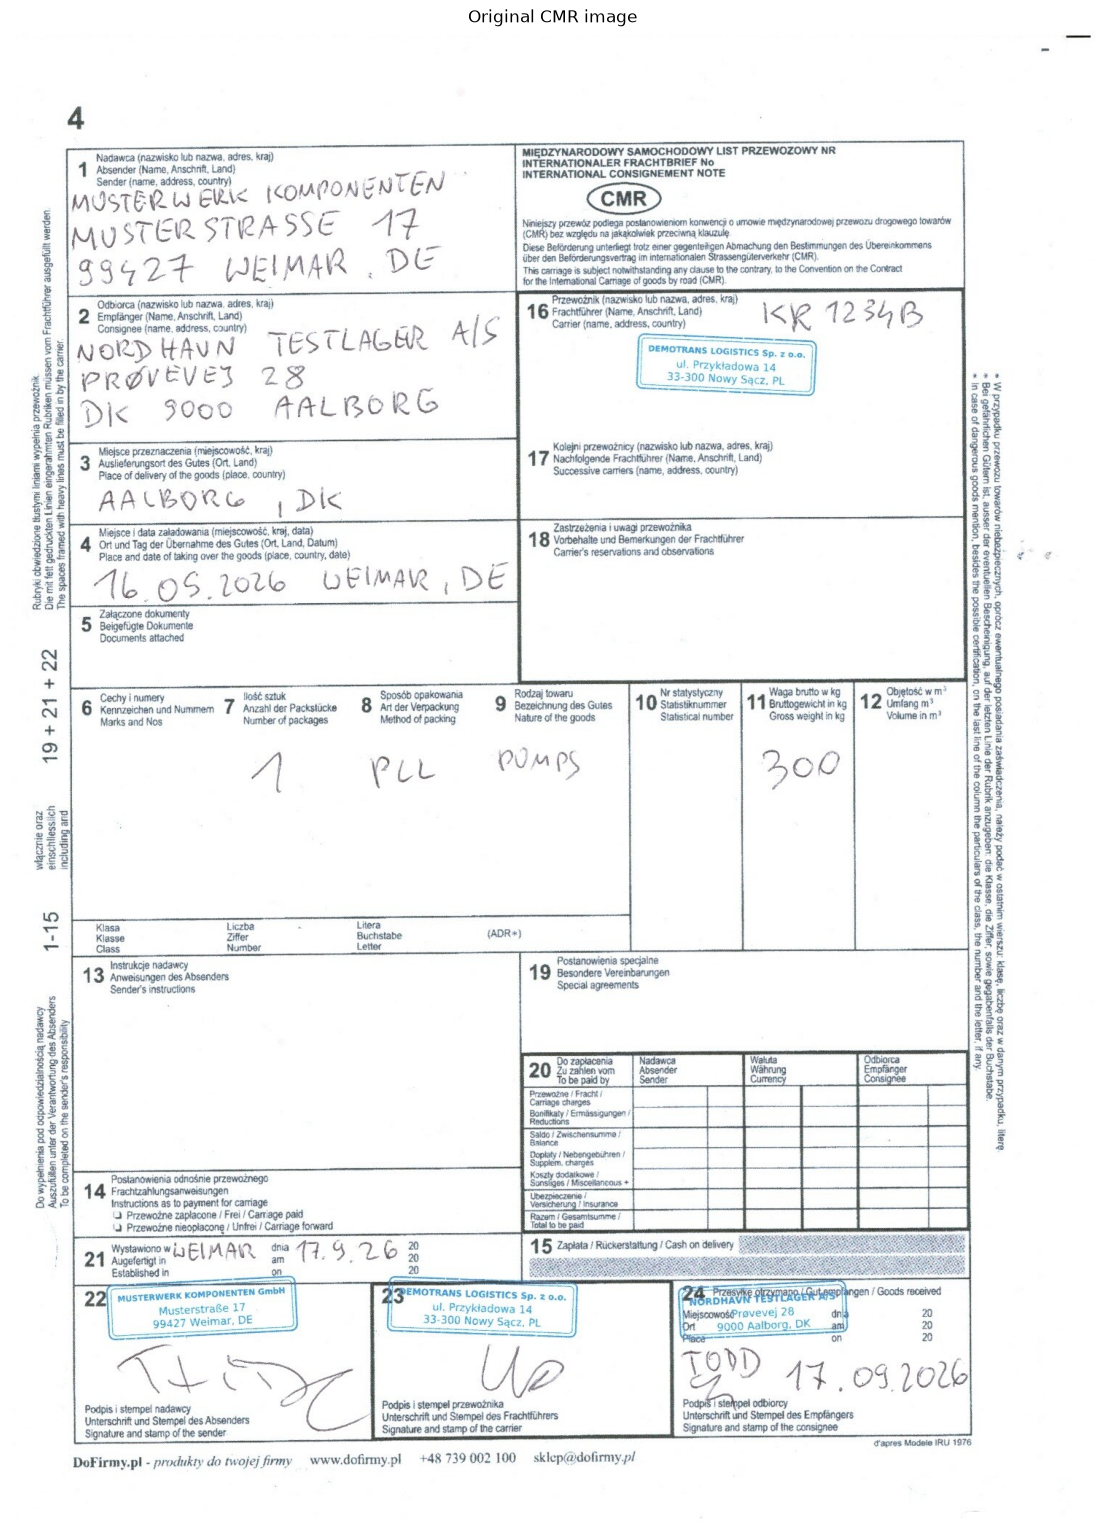

In [9]:


original = Image.open(ORIGINAL_PATH)

plt.figure(figsize=(14, 20))
plt.imshow(original)
plt.axis("off")
plt.title("Original CMR image");

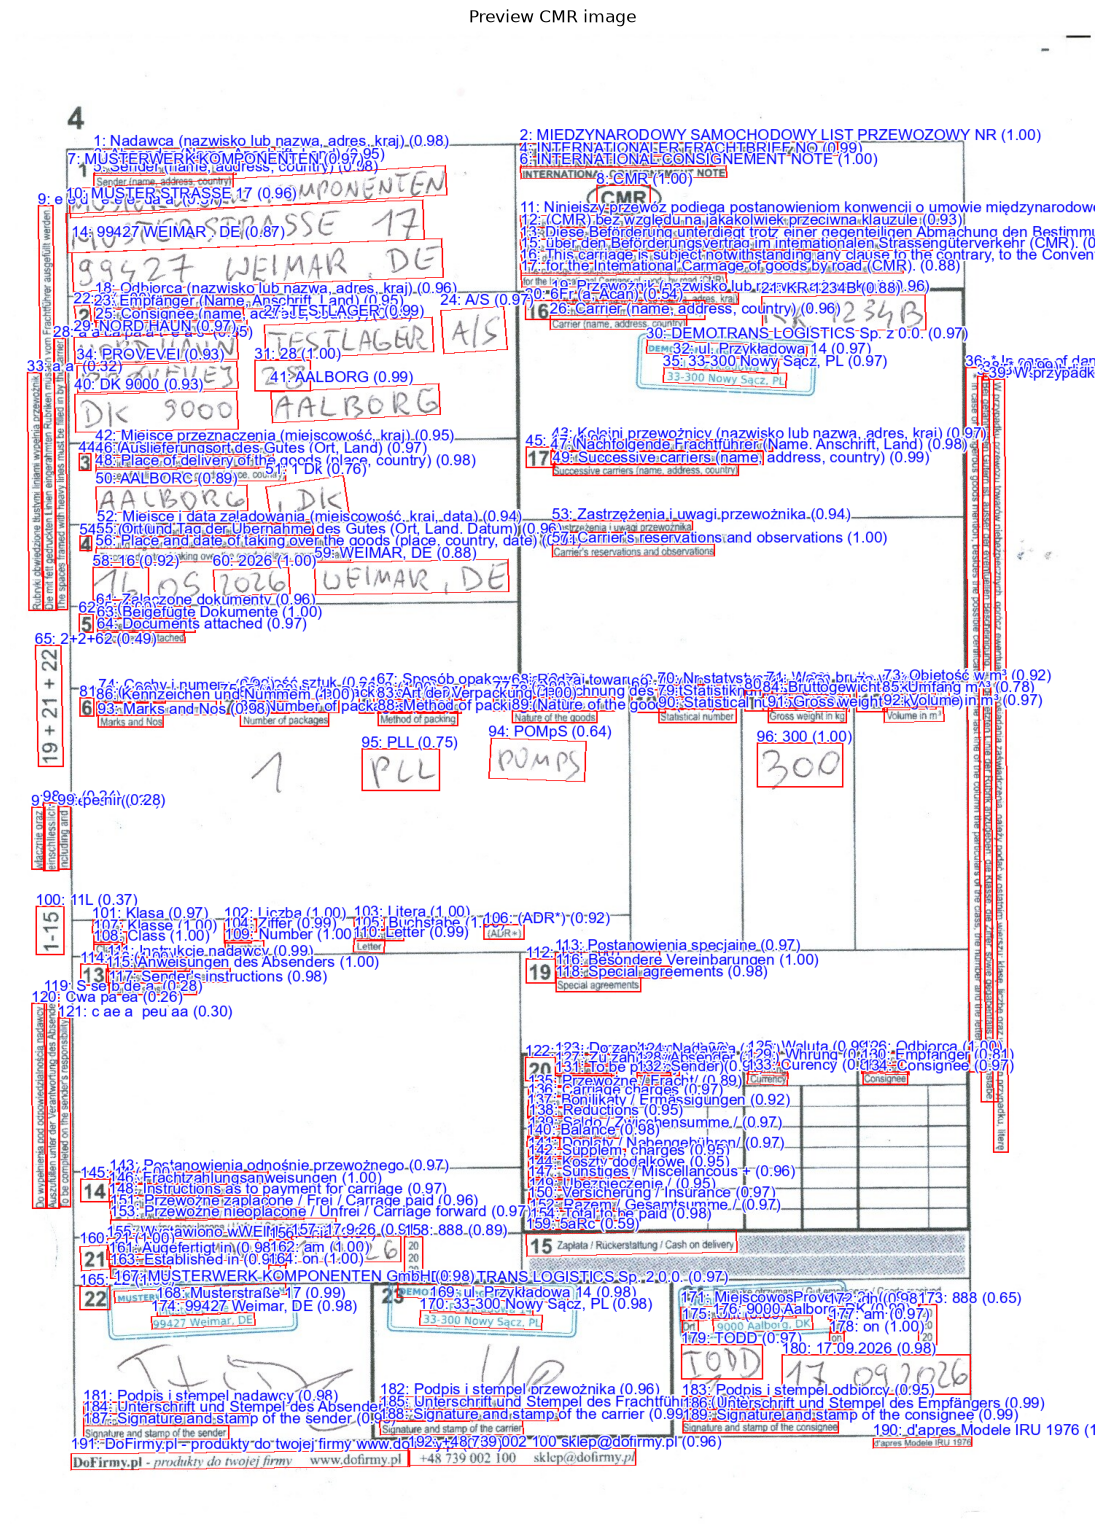

In [10]:
preview = Image.open(PREVIEW_PATH)

plt.figure(figsize=(14, 20))
plt.imshow(preview)
plt.axis("off");
plt.title("Preview CMR image");

In [11]:
with RESULT_PATH.open(encoding="utf-8") as file:
    result = json.load(file)

print("Liczba rozpoznanych fragmentów:", len(result["fragments"]))
print("Dostępne informacje:", result.keys())

Liczba rozpoznanych fragmentów: 192
Dostępne informacje: dict_keys(['source_name', 'original', 'image', 'preview', 'width', 'height', 'fragments'])


In [13]:
fragments = pd.DataFrame(result["fragments"])

print("Liczba wierszy tabeli:", len(fragments))
fragments.head()

Liczba wierszy tabeli: 192


,id,text,score,polygon
0,1,"Nadawca (nazwisko lub nazwa, adres, kraj)",0.980556,"[[114.0, 162.0], [363.0, 159.0], [363.0, 179.0..."
1,2,MIEDZYNARODOWY SAMOCHODOWY LIST PRZEWOZOWY NR,0.998166,"[[699.0, 154.0], [1135.0, 151.0], [1135.0, 171..."
2,3,"Absender (Name, Anschrift, Land)",0.951883,"[[115.0, 179.0], [310.0, 177.0], [310.0, 197.0..."
3,4,INTERNATIONALER FRACHTBRIEF NO,0.993453,"[[699.0, 172.0], [967.0, 169.0], [967.0, 186.0..."
4,5,"Sender (name, address, country)",0.982625,"[[114.0, 195.0], [306.0, 194.0], [306.0, 214.0..."


In [14]:
total = len(fragments)
low = (fragments["score"] < 0.70).sum()
medium = ((fragments["score"] >= 0.70) & (fragments["score"] < 0.90)).sum()
high = (fragments["score"] >= 0.90).sum()

print("Łącznie fragmentów:", total)
print("Niska pewność (< 0.70):", low)
print("Średnia pewność (0.70–0.89):", medium)
print("Wysoka pewność (>= 0.90):", high)
print("Średnia pewność:", round(fragments["score"].mean(), 3))
print("Mediana pewności:", round(fragments["score"].median(), 3))

Łącznie fragmentów: 192
Niska pewność (< 0.70): 16
Średnia pewność (0.70–0.89): 14
Wysoka pewność (>= 0.90): 162
Średnia pewność: 0.921
Mediana pewności: 0.975


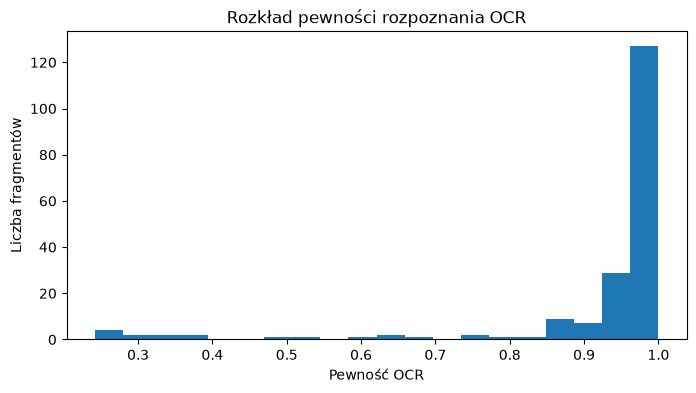

In [15]:
fragments["score"].plot(
    kind="hist",
    bins=20,
    figsize=(8, 4),
    title="Rozkład pewności rozpoznania OCR"
)

plt.xlabel("Pewność OCR")
plt.ylabel("Liczba fragmentów");